# Resolución Facu

In [ ]:
# =========================
# INSTALACIÓN DE LIBRERÍAS
# =========================
# Ejecutar en la terminal solo si faltan librerías:
# python -m pip install pandas numpy matplotlib seaborn xlrd requests beautifulsoup4

In [1]:
# =========================
# IMPORTS Y CONFIGURACIÓN GENERAL
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
import zipfile
import shutil
import requests
from bs4 import BeautifulSoup

sns.set_theme(style="whitegrid")

CARPETA_DATOS = Path("../usu_individual_T216_a_T425/")
CARPETA_ZIPS = Path("../zips_eph")

BASE_URL_EPH = "https://www.indec.gob.ar/ftp/cuadros/menusuperior/eph/"
URL_IPC = "https://www.indec.gob.ar/ftp/cuadros/economia/sh_ipc_aperturas.xls"

AGLOMERADOS = {
    8: "Resistencia",
    31: "Ushuaia - Río Grande"
}

COLUMNAS_USAR = [
    "AGLOMERADO", "ANO4", "CAT_INAC", "CAT_OCUP",
    "CH04", "CH06", "CODUSU", "COMPONENTE",
    "ESTADO", "IPCF", "ITF", "NIVEL_ED",
    "NRO_HOGAR", "P21", "P47T", "PONDERA",
    "PONDIH", "PONDII", "PONDIIO", "PP04B_COD",
    "PP04D_COD", "REGION", "TRIMESTRE",
]

print("✅ Imports y configuración general listos.")

✅ Imports y configuración general listos.


In [2]:
# =========================
# DESCARGA Y PREPARACIÓN DE BASES EPH
# =========================

CARPETA_DATOS = Path("../usu_individual_T216_a_T425")
CARPETA_DATOS.mkdir(parents=True, exist_ok=True)

# Carpeta auxiliar para guardar los ZIP descargados
CARPETA_ZIPS = Path("../zips_eph")
CARPETA_ZIPS.mkdir(parents=True, exist_ok=True)


# Lista de años y trimestres
periodos = []

for anio in range(2016, 2026):
    for trimestre in [1, 2, 3, 4]:
        if anio == 2016 and trimestre == 1:
            continue

        periodos.append((anio, trimestre))

print(f"Períodos a descargar: {len(periodos)}")

for anio, trimestre in periodos:
    nombre_zip = f"EPH_usu_{trimestre}_Trim_{anio}_txt.zip"
    url = BASE_URL_EPH + nombre_zip
    destino_zip = CARPETA_ZIPS / nombre_zip

    print(f"\nIntentando descargar: {nombre_zip}")

    # Descargar si todavía no existe
    if not destino_zip.exists():
        try:
            urlretrieve(url, destino_zip)
            print("  ✅ ZIP descargado")
        except HTTPError as e:
            print(f"  ⚠️ No disponible en INDEC o URL no encontrada: HTTP {e.code}")
            continue
        except URLError as e:
            print(f"  ❌ Error de conexión: {e}")
            continue
    else:
        print("  ℹ️ ZIP ya existe")

    # Descomprimir y copiar solo archivos individuales
    try:
        with zipfile.ZipFile(destino_zip, "r") as zip_ref:
            nombres = zip_ref.namelist()

            archivos_individuales = [
                n for n in nombres
                if "individual" in n.lower() and (n.lower().endswith(".txt") or n.lower().endswith(".csv"))
            ]

            if len(archivos_individuales) == 0:
                print("  ⚠️ No encontré archivo individual dentro del ZIP")
                continue

            for archivo_interno in archivos_individuales:
                nombre_final = Path(archivo_interno).name
                destino_final = CARPETA_DATOS / nombre_final

                if destino_final.exists():
                    print(f"  ℹ️ Ya existe: {nombre_final}")
                    continue

                with zip_ref.open(archivo_interno) as origen, open(destino_final, "wb") as salida:
                    shutil.copyfileobj(origen, salida)

                print(f"  ✅ Extraído: {nombre_final}")

    except zipfile.BadZipFile:
        print("  ❌ El ZIP está dañado o incompleto")

print("\n=========================")
print("Resumen final")
print("=========================")

archivos_finales = list(CARPETA_DATOS.glob("*.txt")) + list(CARPETA_DATOS.glob("*.csv"))

print("Carpeta de datos:", CARPETA_DATOS.resolve())
print("Cantidad de archivos individuales encontrados:", len(archivos_finales))

for archivo in sorted(archivos_finales):
    print(" -", archivo.name)

Períodos a descargar: 39

Intentando descargar: EPH_usu_2_Trim_2016_txt.zip
  ℹ️ ZIP ya existe
  ❌ El ZIP está dañado o incompleto

Intentando descargar: EPH_usu_3_Trim_2016_txt.zip
  ℹ️ ZIP ya existe
  ❌ El ZIP está dañado o incompleto

Intentando descargar: EPH_usu_4_Trim_2016_txt.zip
  ℹ️ ZIP ya existe
  ❌ El ZIP está dañado o incompleto

Intentando descargar: EPH_usu_1_Trim_2017_txt.zip
  ℹ️ ZIP ya existe
  ❌ El ZIP está dañado o incompleto

Intentando descargar: EPH_usu_2_Trim_2017_txt.zip
  ℹ️ ZIP ya existe
  ℹ️ Ya existe: usu_individual_t217.txt

Intentando descargar: EPH_usu_3_Trim_2017_txt.zip
  ℹ️ ZIP ya existe
  ℹ️ Ya existe: usu_individual_t317.txt

Intentando descargar: EPH_usu_4_Trim_2017_txt.zip
  ℹ️ ZIP ya existe
  ℹ️ Ya existe: Usu_Individual_T417.txt

Intentando descargar: EPH_usu_1_Trim_2018_txt.zip
  ℹ️ ZIP ya existe
  ℹ️ Ya existe: usu_individual_t118.txt

Intentando descargar: EPH_usu_2_Trim_2018_txt.zip
  ℹ️ ZIP ya existe
  ℹ️ Ya existe: usu_individual_t218.txt



In [3]:
# =================================
# FUNCIÓN PARA LEER ARCHIVOS EPH
# =================================

def leer_archivo_eph(ruta):
    try:
        df = pd.read_csv(
            ruta,
            sep=";",
            encoding="latin1",
            low_memory=False,
            na_values=["", " ", "NA", "N/A"]
        )
    except UnicodeDecodeError:
        df = pd.read_csv(
            ruta,
            sep=";",
            encoding="utf-8",
            low_memory=False,
            na_values=["", " ", "NA", "N/A"]
        )

    df.columns = df.columns.str.replace('"', '').str.strip().str.upper()

    columnas_existentes = [col for col in COLUMNAS_USAR if col in df.columns]
    df = df[columnas_existentes].copy()

    return df

print("✅ ¡Función de lectura de archivos lista!")


✅ ¡Función de lectura de archivos lista!


In [4]:
# =========================
# CARGA DE TODOS LOS TXT
# =========================

bases = []
archivos = list(CARPETA_DATOS.glob("*.txt")) + list(CARPETA_DATOS.glob("*.csv")) # Buscamos TXT y CSV por si el INDEC varió el formato

if len(archivos) == 0:
    print(f"❌ ERROR: No se encontró ningún archivo .txt o .csv en la carpeta '{CARPETA_DATOS}'.")
    print("Verifica que el nombre de la carpeta esté bien escrito y que esté en el mismo lugar que este archivo de código.")
else:
    print(f"⏳ Se encontraron {len(archivos)} archivos. Iniciando la carga y filtrado...")

    for archivo in archivos:
        df_temp = leer_archivo_eph(archivo) # 1. Lee el archivo original completo
        df_temp = df_temp[df_temp["AGLOMERADO"].isin(AGLOMERADOS.keys())].copy() # 2. Filtramos inmediatamente antes de guardar para evitar colapso de RAM
        df_temp["ARCHIVO_ORIGEN"] = archivo.name # 3. Guardamos el origen y lo enviamos a la lista

        bases.append(df_temp)
        print(f"Procesado: {archivo.name} - Registros retenidos: {len(df_temp)}")

    df = pd.concat(bases, ignore_index=True) # 4. Concatenamos solo los pedacitos (muy amigable con la RAM)
    df["NOMBRE_AGLOMERADO"] = df["AGLOMERADO"].map(AGLOMERADOS) # 5. Agregamos el nombre real del aglomerado

    print("\n✅ Extracción completada. Registros totales cargados de los 2 aglomerados:", len(df))

⏳ Se encontraron 35 archivos. Iniciando la carga y filtrado...
Procesado: usu_individual_t117.txt - Registros retenidos: 2372
Procesado: usu_individual_t118.txt - Registros retenidos: 2410
Procesado: usu_individual_t119.txt - Registros retenidos: 2534
Procesado: usu_individual_T120.txt - Registros retenidos: 2103
Procesado: usu_individual_T121.txt - Registros retenidos: 1939
Procesado: usu_individual_T122.txt.txt - Registros retenidos: 2363
Procesado: usu_individual_T123.txt - Registros retenidos: 2192
Procesado: usu_individual_T124.txt - Registros retenidos: 2200
Procesado: usu_individual_T125.txt - Registros retenidos: 2456
Procesado: usu_individual_t217.txt - Registros retenidos: 2541
Procesado: usu_individual_t218.txt - Registros retenidos: 2593
Procesado: USU_individual_t219.txt - Registros retenidos: 2892
Procesado: usu_Individual_T220.txt - Registros retenidos: 1066
Procesado: usu_individual_T221.txt - Registros retenidos: 2175
Procesado: usu_individual_T222.txt.txt - Registros 

In [5]:
# =========================
# CONTROL DE PERÍODOS CARGADOS
# =========================

control_periodos = (
    df.groupby(["ANO4", "TRIMESTRE", "NOMBRE_AGLOMERADO"])
    .size()
    .reset_index(name="cantidad_registros")
    .sort_values(["ANO4", "TRIMESTRE", "NOMBRE_AGLOMERADO"])
)

control_periodos

,ANO4,TRIMESTRE,NOMBRE_AGLOMERADO,cantidad_registros
0,2017,1,Resistencia,1224
1,2017,1,Ushuaia - Río Grande,1148
2,2017,2,Resistencia,1234
3,2017,2,Ushuaia - Río Grande,1307
4,2017,3,Resistencia,1284
...,...,...,...,...
63,2025,2,Ushuaia - Río Grande,1069
64,2025,3,Resistencia,1173
65,2025,3,Ushuaia - Río Grande,1054
66,2025,4,Resistencia,1229


In [6]:
# =========================
# LIMPIEZA DE EDAD
# =========================

# Aseguramos que la edad sea numérica
df["CH06"] = pd.to_numeric(df["CH06"], errors="coerce")

registros_antes_edad = len(df)

df = df[
    (df["CH06"] >= 16) &
    (df["CH06"] <= 100)
].copy()

registros_despues_edad = len(df)

print("Registros eliminados por edad:", registros_antes_edad - registros_despues_edad)


# =========================
# ELIMINACIÓN DE DUPLICADOS
# =========================

duplicados = df.duplicated().sum()

df = df.drop_duplicates().copy()

print("Duplicados eliminados:", duplicados)


Registros eliminados por edad: 18388
Duplicados eliminados: 0


In [7]:
# =========================
# CONTROL DE EDAD
# =========================

print(df["CH06"].describe())


count    61103.000000
mean        41.994092
std         17.530592
min         16.000000
25%         27.000000
50%         40.000000
75%         55.000000
max        100.000000
Name: CH06, dtype: float64


In [8]:
# =========================
# IDENTIFICACIÓN DE NO RESPUESTA
# =========================

df["P21"] = pd.to_numeric(df["P21"], errors="coerce")
df["P47T"] = pd.to_numeric(df["P47T"], errors="coerce")

df["NO_RESPUESTA_P21"] = df["P21"] == -9
df["NO_RESPUESTA_P47T"] = df["P47T"] == -9
df["NO_RESPUESTA_INGRESOS"] = df["NO_RESPUESTA_P21"] | df["NO_RESPUESTA_P47T"]

# =========================
# BASE PARA INGRESOS
# Conservamos ingresos 0.
# Solo excluimos -9 para análisis descriptivo.
# =========================

df_ingresos = df[
    (df["P21"] != -9) &
    (df["P47T"] != -9)
].copy()

print(f"✅ Base de ingresos validos creada con {len(df_ingresos)} registros.")

✅ Base de ingresos validos creada con 57156 registros.


In [9]:
# =========================
# DETECCIÓN DE ATÍPICOS POR IQR
# =========================

def detectar_atipicos_iqr(dataframe, columna):
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    atipicos = dataframe[
        (dataframe[columna] < limite_inferior) |
        (dataframe[columna] > limite_superior)
    ]

    return limite_inferior, limite_superior, atipicos


lim_inf_p21, lim_sup_p21, atipicos_p21 = detectar_atipicos_iqr(df_ingresos, "P21")
lim_inf_p47t, lim_sup_p47t, atipicos_p47t = detectar_atipicos_iqr(df_ingresos, "P47T")


# =========================
# RESUMEN DE LIMPIEZA
# =========================

resumen_limpieza = pd.DataFrame({
    "Indicador": [
        "Registros finales",
        "Registros para análisis de ingresos",
        "No respuesta P21",
        "No respuesta P47T",
        "No respuesta en algún ingreso",
        "Atípicos P21 según IQR",
        "Atípicos P47T según IQR"
    ],
    "Cantidad": [
        len(df),
        len(df_ingresos),
        df["NO_RESPUESTA_P21"].sum(),
        df["NO_RESPUESTA_P47T"].sum(),
        df["NO_RESPUESTA_INGRESOS"].sum(),
        len(atipicos_p21),
        len(atipicos_p47t)
    ]
})

print("\nResumen de limpieza:\n", resumen_limpieza)


# =========================
# RESUMEN POR AGLOMERADO
# =========================

resumen_por_aglomerado = df.groupby("NOMBRE_AGLOMERADO").agg(
    registros=("CODUSU", "count"),
    edad_media=("CH06", "mean"),
    edad_minima=("CH06", "min"),
    edad_maxima=("CH06", "max"),
    no_respuesta_p21=("NO_RESPUESTA_P21", "sum"),
    no_respuesta_p47t=("NO_RESPUESTA_P47T", "sum")
).reset_index()

print("\nResumen por aglomerado:\n", resumen_por_aglomerado)


# =========================
# GUARDADO DE BASES LIMPIAS
# =========================

df.to_csv("eph_limpia_2016_2025_aglomerados_08_31.csv", index=False, encoding="utf-8-sig")
df_ingresos.to_csv("eph_ingresos_validos_2016_2025_aglomerados_08_31.csv", index=False, encoding="utf-8-sig")
resumen_limpieza.to_csv("resumen_limpieza.csv", index=False, encoding="utf-8-sig")
resumen_por_aglomerado.to_csv("resumen_por_aglomerado.csv", index=False, encoding="utf-8-sig")

print("\nLimpieza finalizada con éxito. Archivos guardados.")


Resumen de limpieza:
                              Indicador  Cantidad
0                    Registros finales     61103
1  Registros para análisis de ingresos     57156
2                     No respuesta P21      3047
3                    No respuesta P47T      3947
4        No respuesta en algún ingreso      3947
5               Atípicos P21 según IQR      8552
6              Atípicos P47T según IQR      8841

Resumen por aglomerado:
       NOMBRE_AGLOMERADO  registros  edad_media  edad_minima  edad_maxima  \
0           Resistencia      33989   41.966607           16          100   
1  Ushuaia - Río Grande      27114   42.028546           16           99   

   no_respuesta_p21  no_respuesta_p47t  
0              2310               2882  
1               737               1065  

Limpieza finalizada con éxito. Archivos guardados.


In [10]:
# =========================
# CARGA DE BASES LIMPIAS PARA ANÁLISIS
# =========================

df = pd.read_csv("./eph_limpia_2016_2025_aglomerados_08_31.csv")
df_ingresos = pd.read_csv("./eph_ingresos_validos_2016_2025_aglomerados_08_31.csv")

print("✅ Datos cargados exitosamente.")
print(f"Base general: {len(df)} filas.")
print(f"Base de ingresos: {len(df_ingresos)} filas.")

✅ Datos cargados exitosamente.
Base general: 61103 filas.
Base de ingresos: 57156 filas.


In [11]:
# =========================
# CÁLCULO DE TASAS LABORALES
# =========================
def calcular_tasas_indec(grupo):
    pt = grupo['PONDERA'].sum() # Población Total
    pea = grupo[grupo['ESTADO'].isin([1, 2])]['PONDERA'].sum() # Población Económicamente Activa

    ocupados = grupo[grupo['ESTADO'] == 1]['PONDERA'].sum()
    desocupados = grupo[grupo['ESTADO'] == 2]['PONDERA'].sum()

    tasa_actividad = (pea / pt) * 100 if pt > 0 else 0
    tasa_empleo = (ocupados / pt) * 100 if pt > 0 else 0
    tasa_desocupacion = (desocupados / pea) * 100 if pea > 0 else 0

    return pd.Series({
        'Tasa_Actividad': tasa_actividad,
        'Tasa_Empleo': tasa_empleo,
        'Tasa_Desocupacion': tasa_desocupacion
    })

print("⏳ Calculando tasas oficiales del mercado laboral...")

df_tasas = df.groupby(['ANO4', 'TRIMESTRE', 'NOMBRE_AGLOMERADO']).apply(calcular_tasas_indec).reset_index()
df_tasas['PERIODO'] = df_tasas['ANO4'].astype(str) + "-T" + df_tasas['TRIMESTRE'].astype(str)

print("✅ Tasas calculadas con éxito.")

⏳ Calculando tasas oficiales del mercado laboral...
✅ Tasas calculadas con éxito.


C:\Users\HERNAN\AppData\Local\Temp\ipykernel_79696\2963665734.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tasas = df.groupby(['ANO4', 'TRIMESTRE', 'NOMBRE_AGLOMERADO']).apply(calcular_tasas_indec).reset_index()


In [12]:
# =========================
# CONTROL DE TASAS CALCULADAS
# =========================

df_tasas.head()
df_tasas.head()

,ANO4,TRIMESTRE,NOMBRE_AGLOMERADO,Tasa_Actividad,Tasa_Empleo,Tasa_Desocupacion,PERIODO
0,2017,1,Resistencia,44.845601,44.225145,1.383537,2017-T1
1,2017,1,Ushuaia - Río Grande,59.037401,54.486885,7.707853,2017-T1
2,2017,2,Resistencia,49.925252,49.107786,1.637381,2017-T2
3,2017,2,Ushuaia - Río Grande,59.625704,55.958136,6.150985,2017-T2
4,2017,3,Resistencia,52.403714,50.637104,3.371154,2017-T3


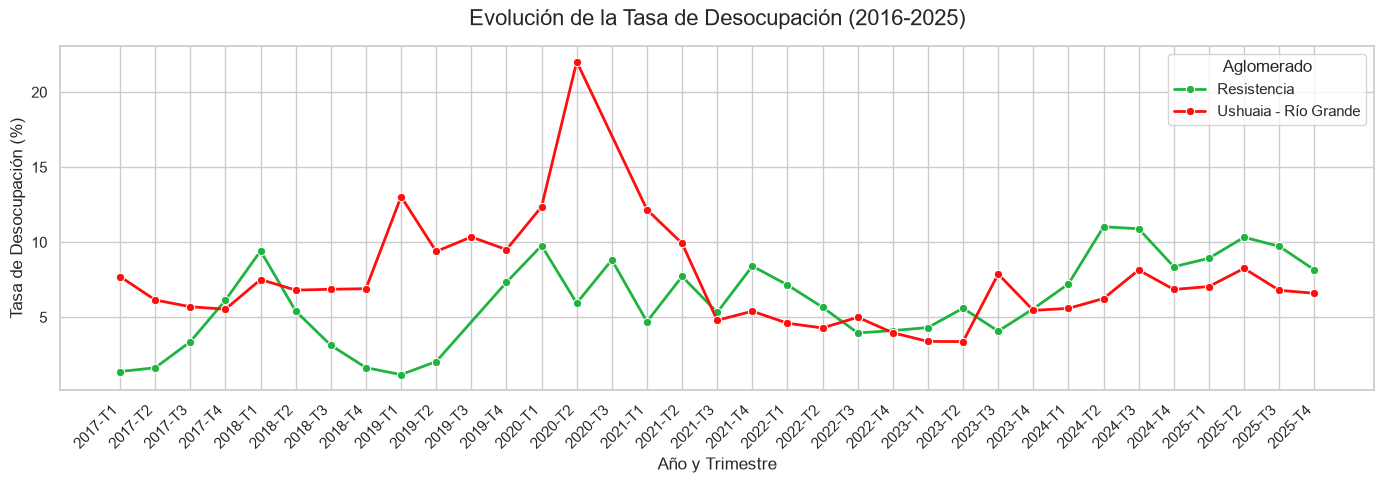

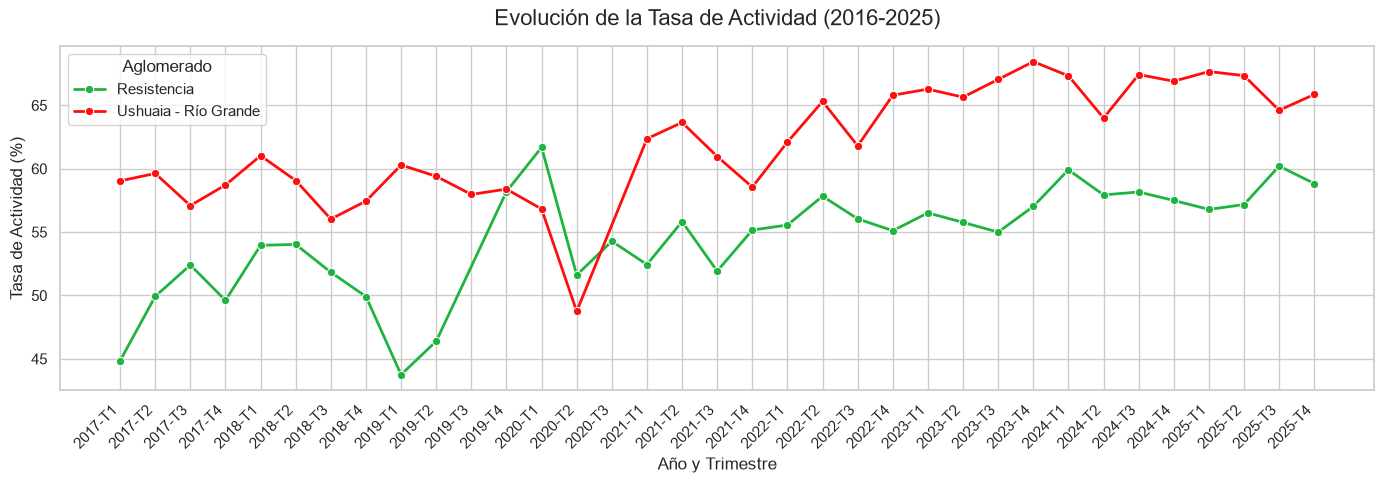

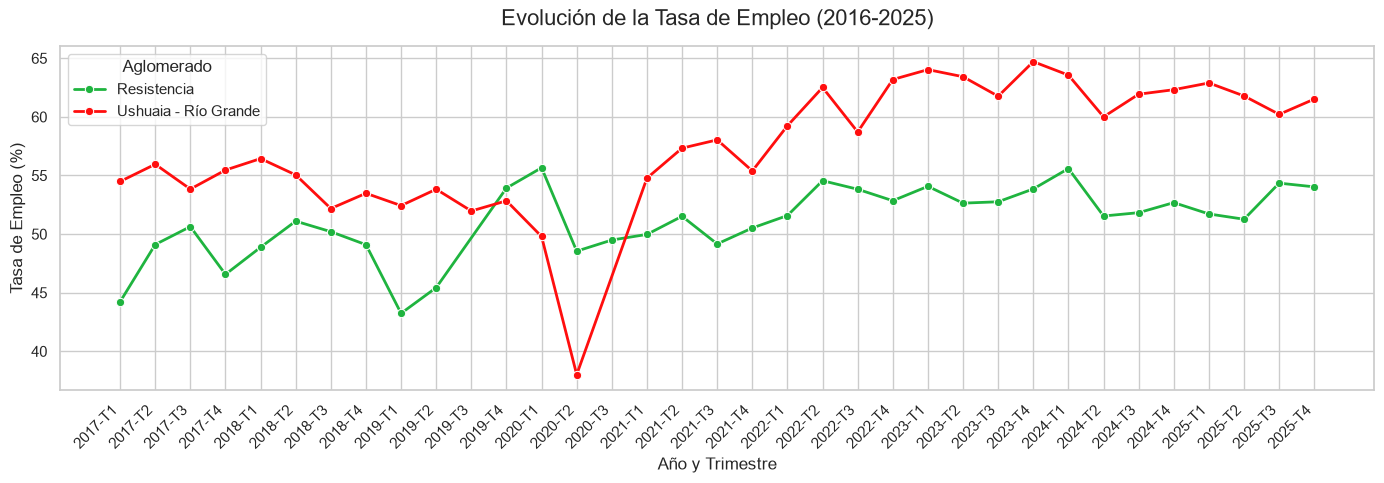

In [13]:
# ===========================
# GRÁFICOS DE TASAS LABORALES
# ===========================
#  Lista de tasas a graficar para automatizar el reporte
tasas = {
    'Tasa_Desocupacion': ('Evolución de la Tasa de Desocupación (2016-2025)', 'Tasa de Desocupación (%)'),
    'Tasa_Actividad': ('Evolución de la Tasa de Actividad (2016-2025)', 'Tasa de Actividad (%)'),
    'Tasa_Empleo': ('Evolución de la Tasa de Empleo (2016-2025)', 'Tasa de Empleo (%)')
}

for columna, (titulo, eje_y) in tasas.items():
    plt.figure(figsize=(14, 5))

    sns.lineplot(
        data=df_tasas,
        x='PERIODO',
        y=columna,
        hue='NOMBRE_AGLOMERADO',
        marker='o',
        linewidth=2,
        palette=["#1fb43f", "#ff0e0e"]
    )

    plt.title(titulo, fontsize=16, pad=15)
    plt.xlabel('Año y Trimestre', fontsize=12)
    plt.ylabel(eje_y, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Aglomerado')
    plt.tight_layout()
    plt.show()

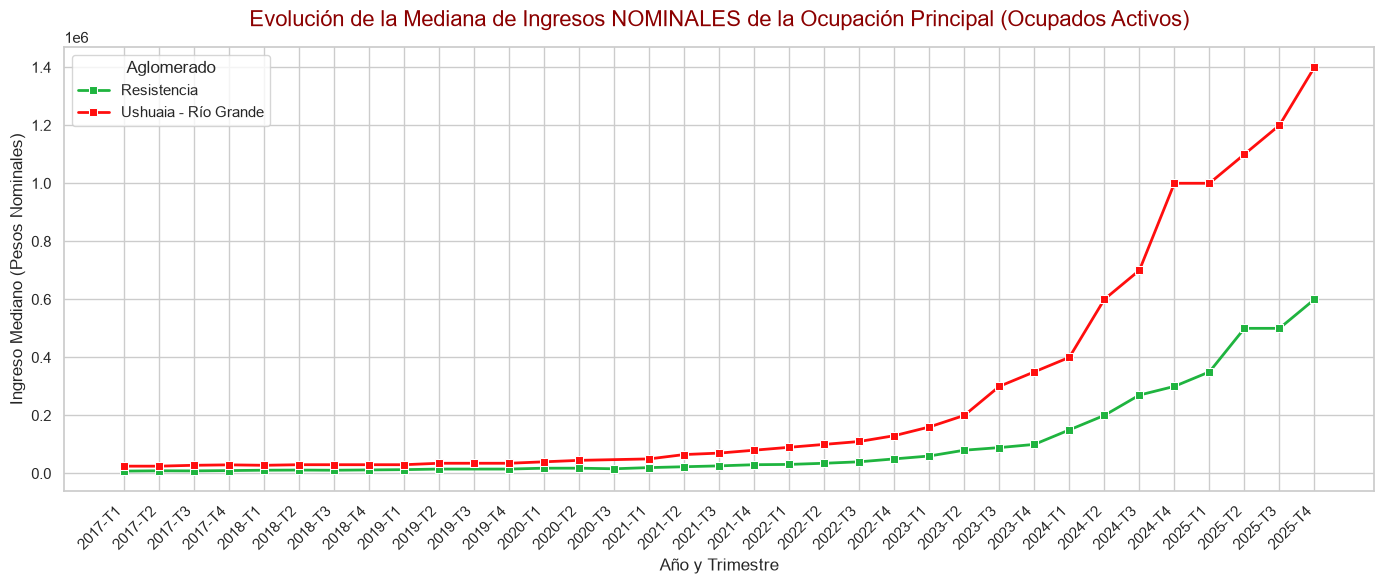

In [14]:

# =================================================
# INGRESOS NOMINALES DE LA OCUPACIÓN PRINCIPAL
# =================================================

# Nos quedamos solo con ocupados (ESTADO == 1) con ingresos positivos (x > 0)
df_ocupados_activos = df_ingresos[(df_ingresos['ESTADO'] == 1) & (df_ingresos['P21'] > 0)].copy()

# Ahora sí, agrupamos calculando la MEDIANA del ingreso de la ocupación principal (P21)
df_ingresos_mediana = df_ocupados_activos.groupby(['ANO4', 'TRIMESTRE', 'NOMBRE_AGLOMERADO'])['P21'].median().reset_index()
df_ingresos_mediana['PERIODO'] = df_ingresos_mediana['ANO4'].astype(str) + "-T" + df_ingresos_mediana['TRIMESTRE'].astype(str)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_ingresos_mediana,
    x='PERIODO',
    y='P21',
    hue='NOMBRE_AGLOMERADO',
    marker='s',
    linewidth=2,
    palette=["#1fb43f", "#ff0e0e"] # Verde y Rojo
)

plt.title('Evolución de la Mediana de Ingresos NOMINALES de la Ocupación Principal (Ocupados Activos)', fontsize=16, pad=15, color='darkred')
plt.xlabel('Año y Trimestre', fontsize=12)
plt.ylabel('Ingreso Mediano (Pesos Nominales)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Aglomerado')
plt.tight_layout()

plt.show()

In [15]:
# =========================
# LECTURA DEL IPC INDEC
# =========================

ipc_raw = pd.read_excel(URL_IPC, header=None)

ipc_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,...,104,105,106,107,108,109,110,111,112,113
0,Índice de precios al consumidor con cobertura ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Período de referencia: Diciembre 2016=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Variaciones mensuales correspondientes a los m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Región GBA,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,...,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Nivel general,1.3,2.5,2.4,2.6,1.3,1.4,1.7,1.5,2,...,1.9,2.1,2.4,2.5,2.8,2.8,2.6,3.4,2.8,2.3
9,Alimentos y bebidas no alcohólicas,1.3,1.8,3.5,2.3,1.1,1.3,1.2,2.2,1.9,...,1.5,2,2.4,2.8,2.6,5.1,3,2.9,1.2,2.8


In [16]:
# =========================
# CONTROL DE REGIONES DISPONIBLES EN IPC
# =========================

ipc_raw[ipc_raw[0].astype(str).str.contains("Región", na=False)][[0]]

,0
5,Región GBA
56,Región Pampeana
105,Región Noroeste
154,Región Noreste
203,Región Cuyo
252,Región Patagonia


In [17]:
# =========================
# CREAR INFLACIÓN TRIMESTRAL POR REGIÓN
# =========================

# Fechas mensuales: están en la fila 5, desde la columna 1 en adelante
fechas = ipc_raw.loc[5, 1:]

# Fila de "Nivel general" para cada región
filas_regiones = {
    "Noreste": 157,      # Región Noreste + 3 filas hasta Nivel general
    "Patagonia": 255    # Región Patagonia + 3 filas hasta Nivel general
}

lista_inflacion = []

for region, fila in filas_regiones.items():
    variaciones = ipc_raw.loc[fila, 1:]

    temp = pd.DataFrame({
        "FECHA": fechas.values,
        "REGION": region,
        "Inflacion_mensual": variaciones.values
    })

    temp["FECHA"] = pd.to_datetime(temp["FECHA"])
    temp["ANO4"] = temp["FECHA"].dt.year
    temp["TRIMESTRE"] = temp["FECHA"].dt.quarter

    lista_inflacion.append(temp)

df_inf_mensual = pd.concat(lista_inflacion, ignore_index=True)

df_inf_mensual.head()

,FECHA,REGION,Inflacion_mensual,ANO4,TRIMESTRE
0,2017-01-01,Noreste,1.7,2017,1
1,2017-02-01,Noreste,1.8,2017,1
2,2017-03-01,Noreste,2.4,2017,1
3,2017-04-01,Noreste,2.2,2017,2
4,2017-05-01,Noreste,1.9,2017,2


In [18]:

# =========================
# CONTROL DE INFLACIÓN MENSUAL POR REGIÓN
# =========================
df_inf_mensual.head(10)

df_inf_mensual["REGION"].value_counts()

REGION
Noreste      113
Patagonia    113
Name: count, dtype: int64

In [19]:
# =========================
# CÁLCULO DE INFLACIÓN TRIMESTRAL POR REGIÓN
# =========================
# Aseguramos que la inflación mensual sea numérica
df_inf_mensual["Inflacion_mensual"] = pd.to_numeric(
    df_inf_mensual["Inflacion_mensual"],
    errors="coerce"
)

# Calculamos inflación trimestral acumulada por región
df_inf_trimestral = (
    df_inf_mensual
    .groupby(["ANO4", "TRIMESTRE", "REGION"])
    .agg(
        Inflacion_trimestral=(
            "Inflacion_mensual",
            lambda x: ((1 + x / 100).prod() - 1) * 100
        )
    )
    .reset_index()
)

df_inf_trimestral.head(10)

,ANO4,TRIMESTRE,REGION,Inflacion_trimestral
0,2017,1,Noreste,6.015334
1,2017,1,Patagonia,6.535428
2,2017,2,Noreste,5.599785
3,2017,2,Patagonia,4.875074
4,2017,3,Noreste,3.848303
5,2017,3,Patagonia,4.567431
6,2017,4,Noreste,5.288995
7,2017,4,Patagonia,5.702100
8,2018,1,Noreste,6.641408
9,2018,1,Patagonia,7.896212


In [20]:
# =========================
# ARMAR ÍNDICE DE PRECIOS ACUMULADO POR REGIÓN
# =========================

df_inf_trimestral = df_inf_trimestral.sort_values(["REGION", "ANO4", "TRIMESTRE"]).copy()

df_inf_trimestral["Factor"] = 1 + (df_inf_trimestral["Inflacion_trimestral"] / 100)

df_inf_trimestral["INDICE_PRECIOS"] = (
    df_inf_trimestral
    .groupby("REGION")["Factor"]
    .cumprod()
)

df_inf_trimestral.head(40)

,ANO4,TRIMESTRE,REGION,Inflacion_trimestral,Factor,INDICE_PRECIOS
0,2017,1,Noreste,6.015334,1.060153,1.060153
2,2017,2,Noreste,5.599785,1.055998,1.119520
4,2017,3,Noreste,3.848303,1.038483,1.162602
6,2017,4,Noreste,5.288995,1.052890,1.224092
8,2018,1,Noreste,6.641408,1.066414,1.305389
10,2018,2,Noreste,8.530896,1.085309,1.416750
12,2018,3,Noreste,15.386128,1.153861,1.634734
14,2018,4,Noreste,10.748175,1.107482,1.810438
16,2019,1,Noreste,13.563703,1.135637,2.056000
18,2019,2,Noreste,9.483542,1.094835,2.250982


In [21]:
# =========================
# PEGAR ÍNDICE DE PRECIOS A LA BASE DE OCUPADOS
# =========================

# Si este bloque se ejecuta más de una vez, eliminamos columnas previas del merge
columnas_a_eliminar = [
    "REGION",
    "INDICE_PRECIOS",
    "INDICE_PRECIOS_x",
    "INDICE_PRECIOS_y"
]

df_ocupados_activos = df_ocupados_activos.drop(
    columns=[col for col in columnas_a_eliminar if col in df_ocupados_activos.columns],
    errors="ignore"
)

# Asignamos región IPC según aglomerado
df_ocupados_activos["REGION"] = df_ocupados_activos["NOMBRE_AGLOMERADO"].map({
    "Resistencia": "Noreste",
    "Ushuaia - Río Grande": "Patagonia"
})

# Dejamos solo columnas necesarias del IPC
df_inf_limpio = df_inf_trimestral[[
    "ANO4", "TRIMESTRE", "REGION", "INDICE_PRECIOS"
]].copy()

# Cruzamos ocupados con índice de precios regional
df_ocupados_activos = pd.merge(
    df_ocupados_activos,
    df_inf_limpio,
    on=["ANO4", "TRIMESTRE", "REGION"],
    how="left"
)

# Control de faltantes
print("Faltantes de índice de precios:", df_ocupados_activos["INDICE_PRECIOS"].isna().sum())

df_ocupados_activos[[
    "ANO4", "TRIMESTRE", "NOMBRE_AGLOMERADO", "REGION", "INDICE_PRECIOS"
]].drop_duplicates().sort_values(["ANO4", "TRIMESTRE", "NOMBRE_AGLOMERADO"]).head(10)

Faltantes de índice de precios: 0


,ANO4,TRIMESTRE,NOMBRE_AGLOMERADO,REGION,INDICE_PRECIOS
0,2017,1,Resistencia,Noreste,1.060153
399,2017,1,Ushuaia - Río Grande,Patagonia,1.065354
7451,2017,2,Resistencia,Noreste,1.119520
7897,2017,2,Ushuaia - Río Grande,Patagonia,1.117291
14954,2017,3,Resistencia,Noreste,1.162602
15405,2017,3,Ushuaia - Río Grande,Patagonia,1.168323
21777,2017,4,Resistencia,Noreste,1.224092
22216,2017,4,Ushuaia - Río Grande,Patagonia,1.234942
842,2018,1,Resistencia,Noreste,1.305389
1362,2018,1,Ushuaia - Río Grande,Patagonia,1.332455


In [22]:
# =========================
# CALCULAR INGRESO REAL
# =========================

df_ocupados_activos["P21_REAL"] = (
    df_ocupados_activos["P21"] / df_ocupados_activos["INDICE_PRECIOS"]
)

df_ocupados_activos.to_csv("eph_deflactada.csv", index=False)

print("✅ Ingreso real calculado correctamente.")
print("Archivo guardado: eph_deflactada.csv")

df_ocupados_activos[[
    "ANO4", "TRIMESTRE", "NOMBRE_AGLOMERADO", "REGION", "P21", "INDICE_PRECIOS", "P21_REAL"
]].head()

✅ Ingreso real calculado correctamente.
Archivo guardado: eph_deflactada.csv


,ANO4,TRIMESTRE,NOMBRE_AGLOMERADO,REGION,P21,INDICE_PRECIOS,P21_REAL
0,2017,1,Resistencia,Noreste,8000.0,1.060153,7546.078164
1,2017,1,Resistencia,Noreste,15000.0,1.060153,14148.896558
2,2017,1,Resistencia,Noreste,12000.0,1.060153,11319.117246
3,2017,1,Resistencia,Noreste,4500.0,1.060153,4244.668967
4,2017,1,Resistencia,Noreste,5000.0,1.060153,4716.298853


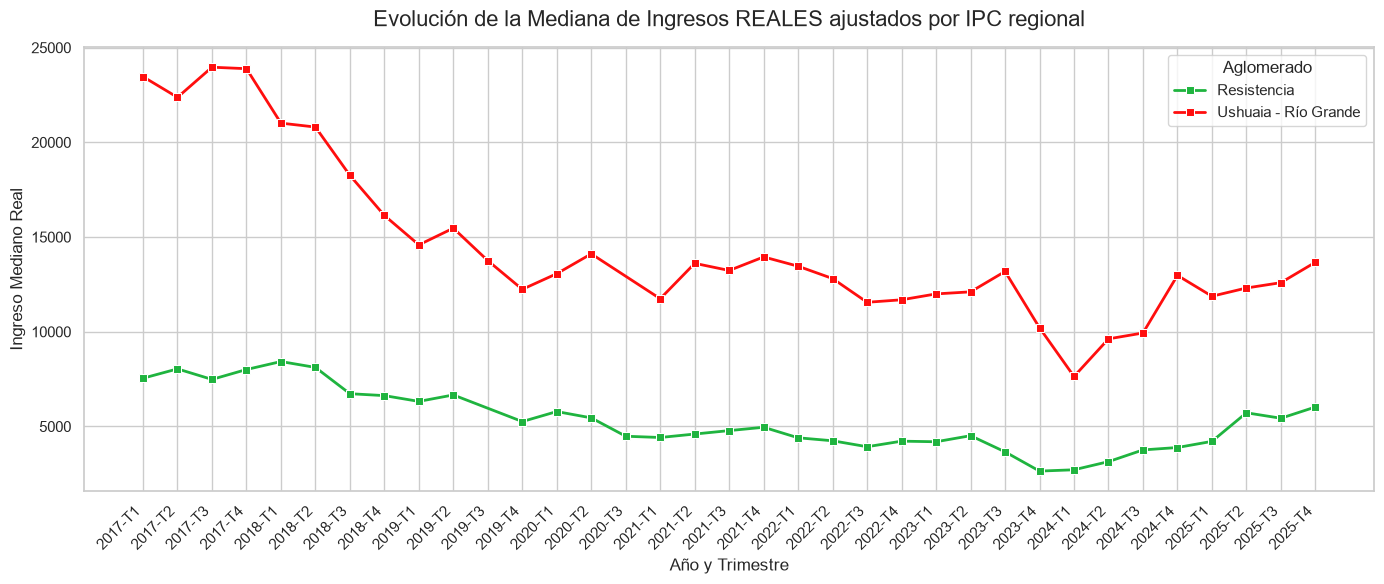

In [23]:
# =========================
# GRÁFICO DE INGRESOS REALES
# =========================
# 1. Agrupamos calculando la MEDIANA del ingreso REAL de la ocupación principal (P21_REAL)
df_ingresos_real_mediana = df_ocupados_activos.groupby(['ANO4', 'TRIMESTRE', 'NOMBRE_AGLOMERADO'])['P21_REAL'].median().reset_index()
df_ingresos_real_mediana['PERIODO'] = df_ingresos_real_mediana['ANO4'].astype(str) + "-T" + df_ingresos_real_mediana['TRIMESTRE'].astype(str)

# 2. Armamos la visualización
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_ingresos_real_mediana,
    x='PERIODO',
    y='P21_REAL',
    hue='NOMBRE_AGLOMERADO',
    marker='s',
    linewidth=2,
    palette=["#1fb43f", "#ff0e0e"] # Mantenemos Verde para Resistencia y Rojo para Ushuaia
)

plt.title('Evolución de la Mediana de Ingresos REALES ajustados por IPC regional', fontsize=16, pad=15)
plt.xlabel('Año y Trimestre', fontsize=12)
# Recordemos que tira error en 2016. 
plt.ylabel('Ingreso Mediano Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Aglomerado')
plt.tight_layout()

plt.show()

In [24]:
# =========================
# BASE 2025 PARA ANÁLISIS SOCIODEMOGRÁFICO
# =========================

print("⏳ Cargando base de datos deflactada...")

# Cargamos la base que ya tiene la columna P21_REAL
df_real = pd.read_csv("./eph_deflactada.csv")

# Filtramos el último año completo disponible
df_2025 = df_real[df_real["ANO4"] == 2025].copy()

# Mapeo de variables categóricas
dic_sexo = {
    1: "Varón",
    2: "Mujer"
}

dic_edu = {
    1: "Primaria Inc.",
    2: "Primaria Comp.",
    3: "Secundaria Inc.",
    4: "Secundaria Comp.",
    5: "Superior Inc.",
    6: "Superior Comp.",
    7: "Sin instrucción"
}

df_2025["SEXO"] = df_2025["CH04"].map(dic_sexo)
df_2025["EDUCACION"] = df_2025["NIVEL_ED"].map(dic_edu)

# Excluimos nivel educativo no especificado
df_2025 = df_2025[df_2025["NIVEL_ED"] != 9].copy()

print("✅ Base 2025 cargada correctamente.")

⏳ Cargando base de datos deflactada...
✅ Base 2025 cargada correctamente.


In [25]:
# =========================
# FUNCIONES PARA CLASIFICAR OCUPACIÓN Y SECTOR
# =========================

def obtener_calificacion(codigo):
    codigo = str(codigo)

    if len(codigo) >= 5:
        digito = codigo[4]  # El 5to dígito indica la calificación ocupacional

        if digito == "1":
            return "Profesional"
        if digito == "2":
            return "Técnica"
        if digito == "3":
            return "Operativa"
        if digito == "4":
            return "No Calificada"

    return "Desconocida"


def obtener_sector(codigo):
    try:
        c = int(str(codigo)[:2])

        if 1 <= c <= 3:
            return "Agro y Minería"
        if 10 <= c <= 33:
            return "Industria"
        if 41 <= c <= 43:
            return "Construcción"
        if 45 <= c <= 47:
            return "Comercio"
        if 49 <= c <= 53:
            return "Transporte"
        if c == 85:
            return "Educación"
        if 86 <= c <= 88:
            return "Salud"

        return "Otros Servicios"

    except:
        return "Desconocido"


print("✅ Funciones de clasificación creadas correctamente.")

✅ Funciones de clasificación creadas correctamente.


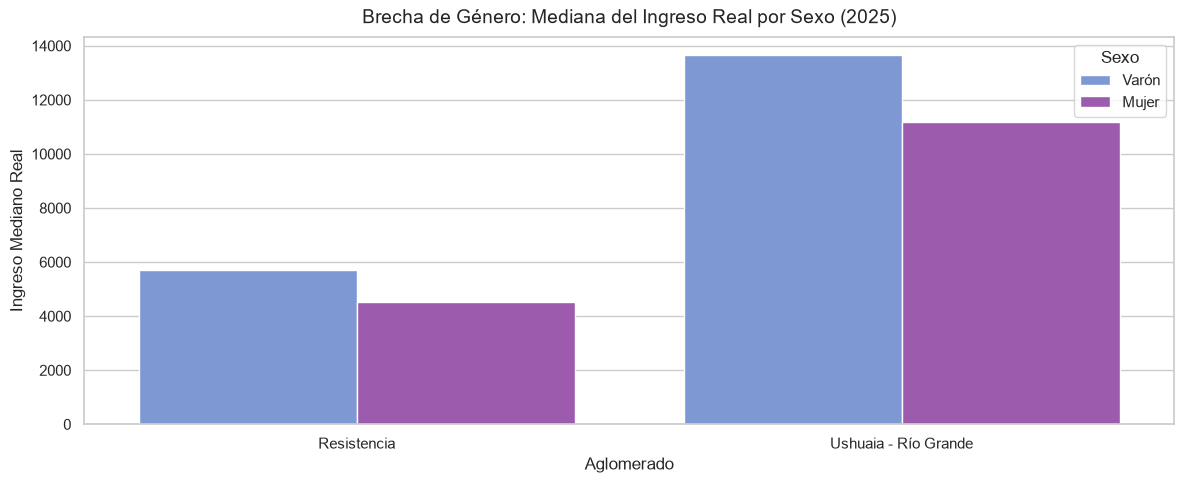

In [26]:
# =========================
# GRÁFICO A: BRECHA DE GÉNERO
# =========================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=df_2025,
    x='NOMBRE_AGLOMERADO',
    y='P21_REAL',
    hue='SEXO',
    palette=["#6e93e2", "#a44eb9"],
    estimator='median',
    errorbar=None
)

plt.title('Brecha de Género: Mediana del Ingreso Real por Sexo (2025)', fontsize=14, pad=10)
plt.xlabel('Aglomerado', fontsize=12)
plt.ylabel('Ingreso Mediano Real', fontsize=12)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

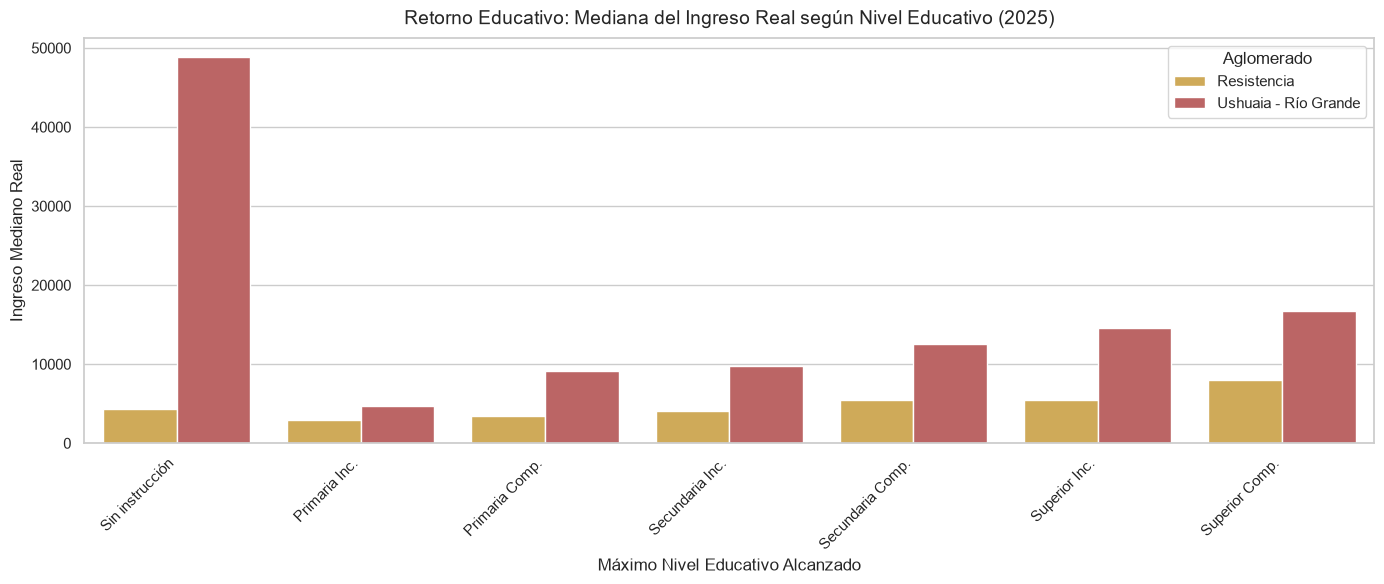

In [27]:
# =========================
# GRÁFICO B: INGRESO REAL SEGÚN NIVEL EDUCATIVO
# =========================

orden_edu = [
    'Sin instrucción',
    'Primaria Inc.',
    'Primaria Comp.',
    'Secundaria Inc.',
    'Secundaria Comp.',
    'Superior Inc.',
    'Superior Comp.'
]

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_2025,
    x='EDUCACION',
    y='P21_REAL',
    hue='NOMBRE_AGLOMERADO',
    palette=["#e2b146", "#ca5656"],
    estimator='median',
    order=orden_edu,
    errorbar=None
)

plt.title('Retorno Educativo: Mediana del Ingreso Real según Nivel Educativo (2025)', fontsize=14, pad=10)
plt.xlabel('Máximo Nivel Educativo Alcanzado', fontsize=12)
plt.ylabel('Ingreso Mediano Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Aglomerado')
plt.tight_layout()
plt.show()

In [28]:
# =========================
# PROCESAMIENTO DE OCUPACIÓN Y SECTOR ECONÓMICO
# =========================

print("⏳ Procesando códigos de ocupación y sector...")

# Calificación ocupacional: PP04D_COD
df_2025["PP04D_COD"] = (
    df_2025["PP04D_COD"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(5)
)

df_2025["CALIFICACION"] = df_2025["PP04D_COD"].apply(obtener_calificacion)

# Sector económico: PP04B_COD
df_2025["PP04B_COD"] = (
    df_2025["PP04B_COD"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

df_2025["SECTOR"] = df_2025["PP04B_COD"].apply(obtener_sector)

# Base para gráficos laborales
df_grafico_empleo = df_2025[
    (df_2025["CALIFICACION"] != "Desconocida") &
    (df_2025["SECTOR"] != "Desconocido")
].copy()

print("✅ Procesamiento de calificaciones y sectores completado.")


⏳ Procesando códigos de ocupación y sector...
✅ Procesamiento de calificaciones y sectores completado.


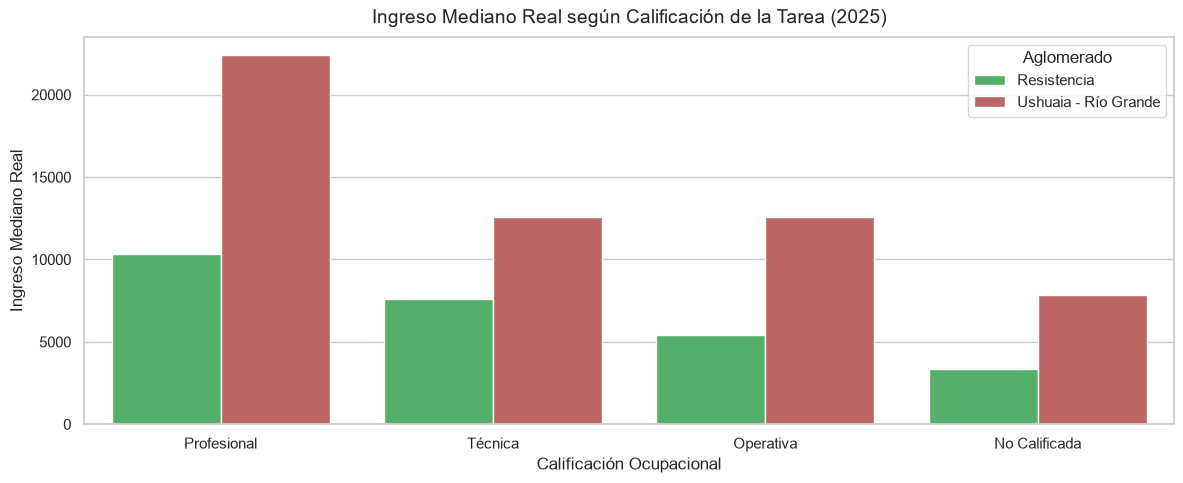

In [29]:
# =========================
# GRÁFICO C: INGRESOS POR CALIFICACIÓN OCUPACIONAL
# =========================

orden_calif = ['Profesional', 'Técnica', 'Operativa', 'No Calificada']

plt.figure(figsize=(12, 5))

sns.barplot(
    data=df_grafico_empleo,
    x='CALIFICACION',
    y='P21_REAL',
    hue='NOMBRE_AGLOMERADO',
    palette=["#45be5f", "#ca5656"],
    estimator='median',
    order=orden_calif,
    errorbar=None
)

plt.title('Ingreso Mediano Real según Calificación de la Tarea (2025)', fontsize=14, pad=10)
plt.xlabel('Calificación Ocupacional', fontsize=12)
plt.ylabel('Ingreso Mediano Real', fontsize=12)
plt.legend(title='Aglomerado')
plt.tight_layout()
plt.show()

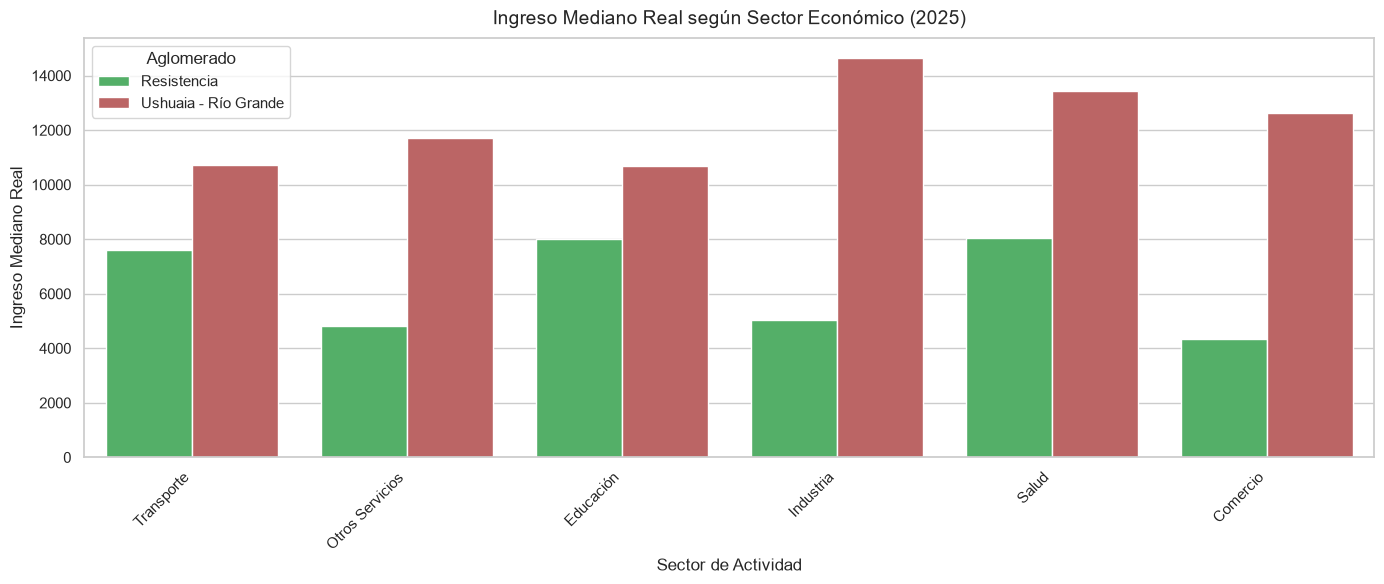

In [30]:
# =========================
# GRÁFICO D: INGRESOS POR SECTOR ECONÓMICO
# =========================

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_grafico_empleo,
    x='SECTOR',
    y='P21_REAL',
    hue='NOMBRE_AGLOMERADO',
    palette=["#45be5f", "#ca5656"],
    estimator='median',
    errorbar=None
)

plt.title('Ingreso Mediano Real según Sector Económico (2025)', fontsize=14, pad=10)
plt.xlabel('Sector de Actividad', fontsize=12)
plt.ylabel('Ingreso Mediano Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Aglomerado')
plt.tight_layout()
plt.show()